# Contents

In this file, several small trainings are performed, to see what the ideal paramters are.

### considerations on the results
- loss: the type of loss chosen does not show relevant differences in the performance of the model
- lr: choosing an higher learning rate led to better results. This conclusion is reasonable, since the numer of train step was limited, to allow multiple experiments. If a larger amount of training step will be chosen, it is suggested to revaluate the lr choice.


## Imports

In [ ]:
!pip install comet_ml
!pip install tqdm
!pip install einops
!pip install torch torchvision
!pip install matplotlib
!pip install torchgeometry
!pip install jpegio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.7/829.7 kB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 50.0 MB/s eta 0:00:00
  Attempting uninstall: python-box
    Found existing installation: python-box 7.4.1
    Uninstalling python-box-7.4.1:
      Successfully uninstalled python-box-7.4.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.7/42.7 kB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 MB 8.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for jpegio: filename=jpegio-0.2.8-cp313-cp313-linux_x86_64.whl size=1342177 sha256=19963b0814973f63a57259e6c7aa9596faff3c811afbebfce154c6bd599054b1
  Stored in directory: /root/.cache/pip/wheels/9e/1e/5c/ba4a3749847e3fbd60d86215f96b3329573329c7b832a62f09
Successfully built jpegio


In [ ]:
import torch
import torchvision
from pathlib import Path
from PIL import Image
import sys
import os
import shutil
from torchvision import transforms
from tqdm import tqdm
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

# jpeg
import jpegio as jio
import numpy as np
import matplotlib.pyplot as plt

# to store best model
from contextlib import redirect_stdout
import io
import json
import gc

# for testing
from torchvision.utils import save_image

In [ ]:
print(torch.cuda.is_available())

True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Configuration
Setting the paths and unzipping the data folder.

In [ ]:
# Base path
BASE_DIR = "/content/drive/MyDrive/Colab Notebooks/tesi/" if 'google.colab' in str(get_ipython()) else "."

# Directories
ZIP_PATH = os.path.join(BASE_DIR, "data", "img_align_celeba.zip")
LOCAL_DATA_ROOT = "/content/raw_data"
SRC_C_D = os.path.join(BASE_DIR, "src", "Cold-Diffusion-Models", "resolution-diffusion-pytorch", "resolution_diffusion_pytorch")

# Path of the resized images
root_train = '/content/dataset_clean/train/'
root_test = '/content/dataset_clean/test/'

# Saving paths
SAVE_ = os.path.join(BASE_DIR, "trained_models", "cold_diffusion", "coeff_truncation", "0_exploring_parameters")
save_path = os.path.join(BASE_DIR, "trained_models", "cold_diffusion", "coeff_truncation", "0_exploring_parameters", "01_model.pt")
config_path = os.path.join(BASE_DIR, "trained_models", "cold_diffusion", "coeff_truncation", "0_exploring_parameters", "model_config.json")

# Clean up folders if they already exist
for folder in [root_train, root_test]:
    if os.path.exists(folder):
        shutil.rmtree(folder)
    os.makedirs(folder)

# importing the models
if SRC_C_D not in sys.path:
    sys.path.append(SRC_C_D)

In [ ]:
if not os.path.exists(LOCAL_DATA_ROOT):
    print("Unzipping ...")
    !unzip -q "{ZIP_PATH}" -d {LOCAL_DATA_ROOT}
    print("Done!")
else:
    print("Already unzipped")

Unzipping ...
error:  zipfile read error
Done!


## Preprocessing

in primis, faccio resize delle immagini per ottenere 128x128 (stessa dimensione che hanno usato nel paper per le immagini delle celebrità)


la cella qua sotto è il *create_data.py* modificato per me

In [ ]:
IMG_SIZE = 128

# PREPROCESSING
# crop the center square (178x178) then resize to IMG_SIZExIMG_SIZE
preprocess = transforms.Compose([
    transforms.CenterCrop(178),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
])

# Find all raw images
exts = ['jpg', 'jpeg']
paths = [p for ext in exts for p in Path(LOCAL_DATA_ROOT).glob(f'**/*.{ext}')]

print(f"Found {len(paths)} images to preprocess")

# PROCESSING LOOP
for idx, path in enumerate(tqdm(paths)):
    try:
        img = Image.open(path)
        img = preprocess(img)

        # Split: 90% Train, 10% Test
        if idx < 0.9 * len(paths):
            img.save(os.path.join(root_train, f"{idx}.jpg"))
        else:
            img.save(os.path.join(root_test, f"{idx}.jpg"))
    except Exception as e:
        print(f"Error processing {path}: {e}")

print(f"Train: {len(os.listdir(root_train))} images | Test: {len(os.listdir(root_test))} images")

Found 91433 images to preprocess


  0%|          | 0/91433 [00:00<?, ?it/s]

Error processing /content/raw_data/img_align_celeba/091433.jpg: cannot identify image file '/content/raw_data/img_align_celeba/091433.jpg'
Train: 82289 images | Test: 9143 images


In [ ]:
# to free space
!rm -rf /content/raw

Found image at: /content/dataset_clean/train/12486.jpg


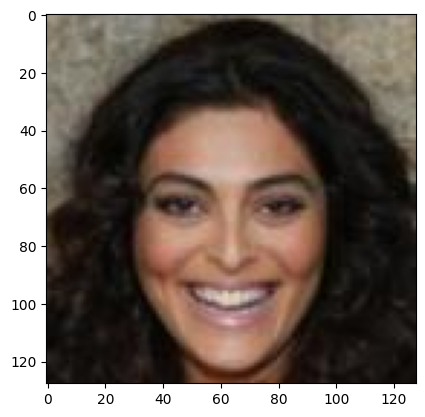

In [ ]:
# sanity check to see preprocessing went well
all_files = []

for root, dirs, files in os.walk(root_train):
    for file in files:
        if file.endswith(('.jpg', '.jpeg')):
            all_files.append(os.path.join(root, file))

if all_files:
    sample_path = all_files[0]
    print(f"Found image at: {sample_path}")
    img = Image.open(sample_path)
    plt.imshow(img)
    plt.show()
else:
    print("No images found.")

## Training
Calling classes declared by the authors of the papers in their folders.

In [ ]:
print(f"Is CUDA available? {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
else:
    print("WARNING: GPU NOT FOUND. Check Runtime Type.")

Is CUDA available? True
Using GPU: Tesla T4


In [ ]:
# to eliminate conflicts with file celeb_128
sys.argv = ['colab_kernel_launcher.py']

from resolution_diffusion_pytorch import Unet, GaussianDiffusion, Trainer

# --- CONFIGURATION ---
class Args:
    time_steps = 10           # Steps to lose information
    train_steps = 5000        # Total iterations
    save_folder = SAVE_
    data_path = root_train
    load_path = None          # Path to weights
    train_routine = 'Final'
    resolution_routine = 'Incremental'
    sampling_routine = 'x0_step_down'
    image_size = IMG_SIZE
    channels = 3

args = Args()

# --- MODEL INITIALIZATION ---
model = Unet(
    dim = 64,
    dim_mults = (1, 2, 4, 8),
    channels = args.channels
).cuda()

diffusion = GaussianDiffusion(
    model,
    image_size = args.image_size,
    device_of_kernel = 'cuda',
    channels = args.channels,
    timesteps = args.time_steps,
    loss_type = 'l1',
    resolution_routine = args.resolution_routine,
    train_routine = args.train_routine,
    sampling_routine = args.sampling_routine
).cuda()

# Support for multiple GPUs if available
if torch.cuda.device_count() > 1:
    diffusion = torch.nn.DataParallel(diffusion)

# dummy wrapper needed to solve conflicts
# expected arg module
class DummyWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.module = model

    def forward(self, *args, **kwargs):
        return self.module(*args, **kwargs)

    # redirect unfound calls to the internal model
    def __getattr__(self, name):
        try:
            return super().__getattr__(name)
        except AttributeError:
            return getattr(self.module, name)

# apply wrapper
if not isinstance(diffusion, torch.nn.DataParallel):
    diffusion = DummyWrapper(diffusion)
    print("DummyWrapper aggiornato")

Is Time embed used ?  True
DummyWrapper aggiornato


### Personalized degradation function

Defining the new degradation function. Each degradation step remove some coefficients. The last step has only the DC.

In [ ]:
def jpegio_degradation(img_batch, step):
    """
    Degradation function that uses the jpegio libreary.

    At each step some more coefficients are set to zero.

    Last step keeps only the DC.
    """
    device = img_batch.device
    batch_size = img_batch.shape[0]
    out_tensors = []

    for b in range(batch_size):
        img_tensor = img_batch[b]

        # From tensor to PIL
        # jpegio library does not allow to work directly on CPU
        img_np = ((img_tensor.detach().cpu().permute(1, 2, 0).numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
        img_pil = Image.fromarray(img_np)

        temp_name = f"temp_b{b}_{os.getpid()}.jpg"
        img_pil.save(temp_name, quality=100, subsampling=0)

        jpeg_struct = jio.read(temp_name)
        keep_size = max(1, int(8 - (step / (args.time_steps - 1)) * 7))

        for i in range(len(jpeg_struct.coef_arrays)):
            arr = jpeg_struct.coef_arrays[i]
            h, w = arr.shape

            # setting coefficients to zero
            mask = np.zeros((8, 8))
            mask[:keep_size, :keep_size] = 1

            # applying the mask
            for row in range(0, h, 8):
                for col in range(0, w, 8):
                    res = arr[row:row+8, col:col+8] * mask
                    arr[row:row+8, col:col+8] = res.astype(np.int32)

        # rewrite images with less coefficients
        jio.write(jpeg_struct, temp_name)
        img_final = Image.open(temp_name)

        # back to tensot
        out_np = np.array(img_final).astype(np.float32)
        out_t = torch.from_numpy(out_np).permute(2, 0, 1)
        out_t = (out_t / 127.5) - 1.0
        out_tensors.append(out_t)

        # cleaning
        if os.path.exists(temp_name):
            os.remove(temp_name)

    return torch.stack(out_tensors).to(device)

# --- OVERWRITING DEGRADATION FUNCTION ---
inner_model = diffusion.module if hasattr(diffusion, 'module') else diffusion
inner_model.func = [lambda img, s=i: jpegio_degradation(img, s) for i in range(args.time_steps)]

Now I visualize a degradated image to see if the degradation function properly works.

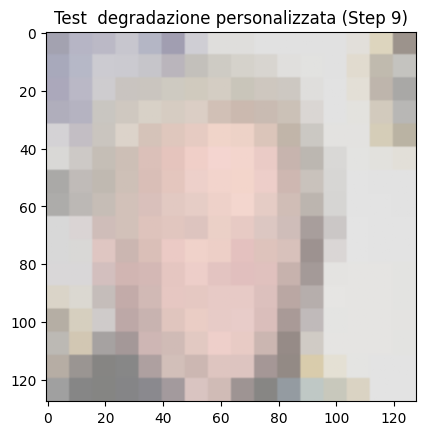

In [ ]:
# --- TESTING THE NEW DEFINED FUNCTION ---

# Define x_0 as a torch.Tensor
img_path = '/content/dataset_clean/train/0.jpg'
img = Image.open(img_path)
transform = transforms.Compose([transforms.Resize((args.image_size, args.image_size)), transforms.ToTensor()])
x_0 = transform(img).unsqueeze(0).cuda() # move to GPU

# maximum degradation
t_test = torch.tensor([args.time_steps - 1], device='cuda')

x_degr = inner_model.q_sample(x_0, t_test)

plt.imshow(((x_degr.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().detach().numpy().clip(0, 1))
plt.title(f"Test  degradation function (Step {t_test.item()})")
plt.show()

### Hyperparameter optimization
Now we can train

In [ ]:
# --- TRAINER ---
trainer = Trainer(
    diffusion,
    args.data_path,
    image_size = args.image_size,
    train_batch_size = 4,
    train_lr = 2e-5,
    train_num_steps = args.train_steps,
    gradient_accumulate_every = 2,
    ema_decay = 0.995,
    fp16 = False,
    results_folder = args.save_folder,
    load_path = args.load_path,
    dataset = 'custom',
)

In [ ]:
# HELPER FUNCTIONS
# psnr loss computation
def calculate_psnr(img1, img2):
    # from [-1, 1] to [0, 1] for PSNR computation
    img1 = (img1.detach() + 1.0) / 2.0
    img2 = (img2.detach() + 1.0) / 2.0
    mse = torch.mean((img1 - img2) ** 2)
    if mse == 0: return 100.0
    return (20 * torch.log10(1.0 / torch.sqrt(mse))).item()

# to reset the weights after each training
def weight_reset(m):
    """
    Goes through each layer of the model and resets the weights.
    """
    if isinstance(m, torch.nn.Conv2d) or isinstance(m, torch.nn.Linear):
        m.reset_parameters()
    if isinstance(m, torch.nn.BatchNorm2d):
        m.reset_parameters()

### Trainings

In [ ]:
# --- POSSIBLE PARAMETER CONFIGURATIONS ---
param_grid = {
    'lr': [1e-4, 1e-5, 1e-6],
    'loss_type': ['l1', 'l2']
}
best_psnr = -float('inf')
best_params = {}
os.makedirs("BestModel_Weights", exist_ok=True)

# fix validation image for a fair comparison
val_batch = next(iter(trainer.dl)).cuda()
val_img = val_batch[0:1]

results_log = []

for lr in param_grid['lr']:
            for l_type in param_grid['loss_type']:
                print(f"\n Current Parameters: LR={lr}, Loss Type={l_type}")

                # REINSTANCIATE MODEL each iteration
                model = Unet(
                            dim = 64,
                            dim_mults = (1, 2, 4, 8),
                            channels = args.channels
                        ).cuda()

                diffusion = GaussianDiffusion(
                    model,
                    image_size = args.image_size,
                    device_of_kernel = 'cuda',
                    channels = args.channels,
                    timesteps = args.time_steps,
                    loss_type = l_type, # here
                    resolution_routine = args.resolution_routine,
                    train_routine = args.train_routine,
                    sampling_routine = args.sampling_routine
                ).cuda()

                if torch.cuda.device_count() > 1:
                    diffusion = torch.nn.DataParallel(diffusion)
                # Apply DummyWrapper if not DataParallel, to ensure 'module' attribute exists
                # This mirrors the global setup and ensures Trainer can access .module.image_size
                elif not isinstance(diffusion, DummyWrapper):
                    diffusion = DummyWrapper(diffusion)

                trainer = Trainer(
                    diffusion,
                    args.data_path,
                    image_size = args.image_size,
                    train_batch_size = 8,
                    train_lr = lr,
                    train_num_steps = 2000,
                    ema_decay = 0.995,
                    fp16 = False,
                    results_folder = args.save_folder,
                    load_path = args.load_path,
                    dataset = 'custom'
                    )

                # to reduce verbosity
                f = io.StringIO()
                with redirect_stdout(f):
                    trainer.train()


                # PSNR EVALUATION
                # The 'inner_model' for evaluation also needs to correctly access the underlying model
                inner_model_eval = diffusion.module if hasattr(diffusion, 'module') else diffusion
                inner_model_eval.eval()

                with torch.no_grad():
                    # reconstructing from the degraded image
                    xt, _, final_img = inner_model_eval.sample(batch_size=1, img=val_img)

                    # computing PSNR between original and reconstructed image
                    current_psnr = calculate_psnr(val_img, final_img)

                inner_model_eval.train()

                print(f"Result PSNR: {current_psnr:.2f} dB")

                # saving the best model
                if current_psnr > best_psnr:
                    best_psnr = current_psnr
                    best_params['lr'] = lr
                    best_params['loss_type'] = l_type

                    with open("BestModel_Weights/config_ottimale.json", "w") as f:
                        json.dump(best_params, f, indent=4)

                    print(f"Current best configuration saved in config_ottimale.json")

                    results_log.append({'lr': lr, 'loss_type': l_type, 'psnr': current_psnr})

                # cleaning the model so that it does not run out of memory
                del trainer
                del diffusion
                del model

                gc.collect()            # clean RAM
                torch.cuda.empty_cache() # empty GPU cache

print(f"\n End of optimization loop")
print(f"Best Parameters: {best_params} (PSNR: {best_psnr:.2f} dB)")


 Current Parameters: LR=0.0001, Loss Type=l1
Is Time embed used ?  True
Result PSNR: 35.43 dB
Current best configuration saved in config_ottimale.json

 Current Parameters: LR=0.0001, Loss Type=l2
Is Time embed used ?  True
Result PSNR: 34.45 dB

 Current Parameters: LR=1e-05, Loss Type=l1
Is Time embed used ?  True
Result PSNR: 28.60 dB

 Current Parameters: LR=1e-05, Loss Type=l2
Is Time embed used ?  True
Result PSNR: 28.99 dB

 Current Parameters: LR=1e-06, Loss Type=l1
Is Time embed used ?  True
Result PSNR: 27.80 dB

 Current Parameters: LR=1e-06, Loss Type=l2
Is Time embed used ?  True
Result PSNR: 27.51 dB

 End of optimization loop
Best Parameters: {'lr': 0.0001, 'loss_type': 'l1'} (PSNR: 35.43 dB)


Ho finito la GPU, quindi poi hard coderò i seguenti parametri:

Best Parameters: {'lr': 0.0001, 'batch_size': 8, 'dim_mults': (1, 2, 4, 8), 'loss_type': 'l1'} (PSNR: 31.99 dB)


In [ ]:
os.makedirs("BestModel_Weights", exist_ok=True)
best_params = {}

best_params['lr'] = 0.0001
best_params['batch_size'] = 8
best_params['dim_mults'] = (1, 2, 4, 8)
best_params['loss_type'] = 'l1'

with open("BestModel_Weights/config_ottimale.json", "w") as f:
    json.dump(best_params, f, indent=4)

### Loading the best model and train
Here is the code for eventually train the best model with higher steps. The code is commented, it was not run.




In [ ]:
# Loading best configuration
with open("BestModel_Weights/config_ottimale.json", "r") as f:
    config = json.load(f)

print(f"Final Training: LR={config['lr']}, BS={config['batch_size']}, Dim Mults={config['dim_mults']}, Loss Type={config['loss_type']}")

config_params = {
    'lr': config['lr'],
    'batch_size': config['batch_size'],
    'dim_mults': tuple(config['dim_mults']),    # Unet expects a tuple for dim_mults
    'loss_type': config['loss_type']
}

Final Training: LR=0.0001, BS=8, Dim Mults=[1, 2, 4, 8], Loss Type=l1


In [ ]:
# Loading best configuration
with open("BestModel_Weights/config_ottimale.json", "r") as f:
    config = json.load(f)

print(f"Final Training: LR={config['lr']}, BS={config['batch_size']}, Dim Mults={config['dim_mults']}, Loss Type={config['loss_type']}")

config_params = {
    'lr': config['lr'],
    'batch_size': config['batch_size'],
    'dim_mults': tuple(config['dim_mults']),    # Unet expects a tuple for dim_mults
    'loss_type': config['loss_type']
}

# Initialization
model_final = Unet(
    dim = 64,
    dim_mults = config_params['dim_mults'],
    channels = args.channels
).cuda()

diffusion_final = GaussianDiffusion(
      model_final,
      image_size = args.image_size,
      device_of_kernel = 'cuda',
      channels = args.channels,
      timesteps = args.time_steps,
      loss_type = config_params['loss_type'],
      resolution_routine = args.resolution_routine,
      train_routine = args.train_routine,
      sampling_routine = args.sampling_routine
).cuda()

if torch.cuda.device_count() > 1:
    diffusion_final = torch.nn.DataParallel(diffusion_final)
elif not isinstance(diffusion_final, DummyWrapper):
    diffusion_final = DummyWrapper(diffusion_final)

trainer_final = Trainer(
    diffusion_final,
    args.data_path,
    image_size = args.image_size,
    train_batch_size = config_params['batch_size'],
    train_lr = config_params['lr'],
    train_num_steps = 5000,
    ema_decay = 0.995,
    fp16 = False,
    results_folder = args.save_folder,
    load_path = args.load_path,
    dataset = 'custom'
    )

# per ripartire dagli step fatti nell'ottimizzazione
# diffusion_final.load_state_dict(torch.load("BestModel_Weights/best_model_init.pt"))

# trainer_final.train()

Final Training: LR=0.0001, BS=8, Dim Mults=[1, 2, 4, 8], Loss Type=l1
Is Time embed used ?  True


In [ ]:
# losses = []
# temp_losses = []
# acc_step = trainer_final.gradient_accumulate_every

# inner_model = diffusion_final.module if hasattr(diffusion_final, 'module') else diffusion_final
# original_loss_fn = inner_model.forward

# def forward_wrapper(*args, **kwargs):
#     loss = original_loss_fn(*args, **kwargs)
#     temp_losses.append(loss.item())

#     # If it did enough steps
#     if len(temp_losses) == acc_step:
#         avg_loss = sum(temp_losses) / len(temp_losses)
#         losses.append(avg_loss) # salvo solo la media dello step
#         temp_losses.clear()     # svuoto per lo step successivo

#     return loss

# inner_model.forward = forward_wrapper

# print(f"---- TRAINING ({args.train_steps} step = {args.train_steps} loss) ----")
# trainer_final.train()

In [ ]:
# if len(losses) > 0:
#     plt.figure(figsize=(10, 5))
#     plt.plot(losses, label='Train Loss', color='#3498db', alpha=0.5)

#     plt.title('Loss Curve')
#     plt.xlabel('Step')
#     plt.ylabel('Loss')
#     plt.grid(True, alpha=.3)
#     plt.legend()

#     # saving the learning curve
#     os.makedirs(args.save_folder, exist_ok=True)
#     plt.savefig(f"{args.save_folder}/learning_curve_manual.png")
#     plt.show()
# else:
#     print("No loss found, problems in training")


Now I save the model so that I will be able to reload it in the future

In [ ]:
# # parameters already saved before
# with open(config_path, 'w') as f:
#     json.dump(config_params, f)

# # saving the weights
# torch.save(diffusion_final.state_dict(), save_path)

# print(f"Model saved")

Code to reload the trained model:

In [ ]:
# same architecture as training one
model_final = Unet(
    dim = 64,
    dim_mults = config_params['dim_mults'],
    channels = args.channels
).cuda()

diffusion_final = GaussianDiffusion(
      model_final,
      image_size = args.image_size,
      device_of_kernel = 'cuda',
      channels = args.channels,
      timesteps = args.time_steps,
      loss_type = config_params['loss_type'],
      resolution_routine = args.resolution_routine,
      train_routine = args.train_routine,
      sampling_routine = args.sampling_routine
).cuda()

if torch.cuda.device_count() > 1:
    diffusion_final = torch.nn.DataParallel(diffusion_final)
elif not isinstance(diffusion_final, DummyWrapper):
    diffusion_final = DummyWrapper(diffusion_final)

# Loading saved weights
state_dict = torch.load(save_path)
diffusion_final.load_state_dict(state_dict)

print("Reloaded model")

Is Time embed used ?  True
Reloaded model


## Visualization
The following cell contains both degradation and reconstruction

Degradation (DCT)...


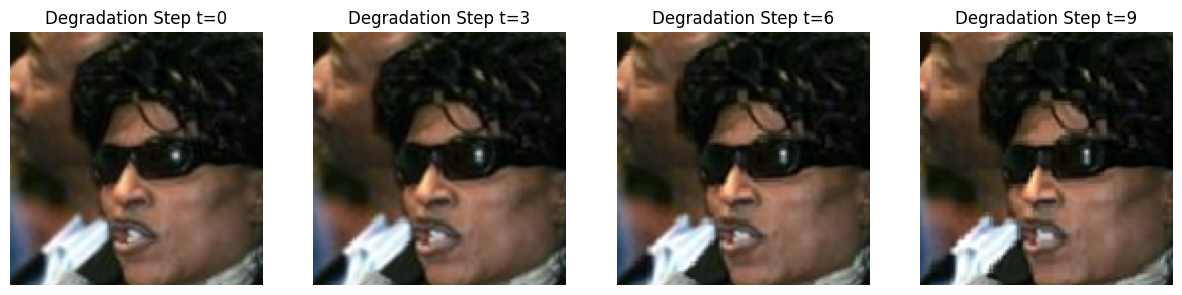

Reconstruction ...


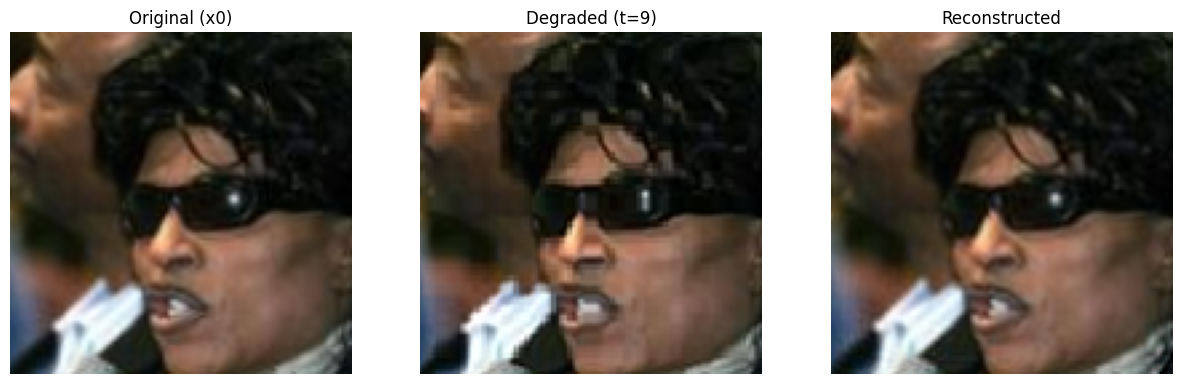

In [ ]:
# preparation
inner_model = diffusion_final.module if hasattr(diffusion_final, 'module') else diffusion_final
test_batch = next(trainer_final.dl).cuda() # taking a batch
x_0 = test_batch[0:1]               # taking first image of the batch

# visualization parameters
steps_to_show = [0, 3, 6, 9]
n_steps = len(steps_to_show)

# --- DEGRADATION ---
print("Degradation (DCT)...")
fig, axs = plt.subplots(1, n_steps, figsize=(15, 5))
for i, t in enumerate(steps_to_show):
    with torch.no_grad():
        x_t = inner_model.q_sample(x_0, torch.tensor([t], device='cuda'))

    # From [-1, 1] to [0, 1]
    img_vis = ((x_t.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy()
    axs[i].imshow(img_vis.clip(0, 1))
    axs[i].set_title(f"Degradation Step t={t}")
    axs[i].axis('off')
plt.show()

# --- RECONSTRUCTION ---
print("Reconstruction ...")

with torch.no_grad():
    # .sample() returns (degraded_img, direct_reconstruction, final_img)
    xt, direct_recons, final_img = inner_model.sample(batch_size=1, img=x_0)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

# Original Image
axs[0].imshow(((x_0.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy().clip(0, 1))
axs[0].set_title("Original (x0)")

# Maximum degradation
axs[1].imshow(((xt.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy().clip(0, 1))
axs[1].set_title("Degraded (t=9)")

# Reconstruction
axs[2].imshow(((final_img.squeeze().permute(1, 2, 0) + 1) * 0.5).cpu().numpy().clip(0, 1))
axs[2].set_title("Reconstructed")

for ax in axs: ax.axis('off')
plt.show()

# Test

I test the trained model on the test set

In [ ]:
# paths
root_test = '/content/dataset_clean/test/'
device = "cuda"

to_tensor = transforms.ToTensor()

test_files = [os.path.join(root_test, f) for f in os.listdir(root_test)][:500] # Testing on 500 images

results_psnr = []
diffusion_final.eval()

print(f"Test on {len(test_files)} clear images")

with torch.no_grad():
    for i, path in enumerate(test_files):
        gt_img = Image.open(path)
        gt_tensor = to_tensor(gt_img).unsqueeze(0).to(device) # [1, 3, 64, 64]

        _, _, restored = diffusion_final.sample(batch_size=1, img=gt_tensor)

        # Copmute psnr
        psnr = calculate_psnr(gt_tensor, restored)
        results_psnr.append(psnr)

        # Save best examples
        if i < 10:
            comparison = torch.cat([gt_tensor, restored], dim=-1)
            save_image(comparison, f"result_test_{i}.png")

print(f"\n Final PSNR: {sum(results_psnr)/len(results_psnr):.2f} dB")

Test on 500 clear images

 Final PSNR: 42.03 dB
